Import

In [66]:
import pandas as pd
import numpy as np
from os import listdir
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedGroupKFold, train_test_split

from pathlib import Path
import shutil
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner

In [67]:
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

EDA

In [69]:
if is_colab():
    base_path = kagglehub.dataset_download('paultimothymooney/breast-histopathology-images') + "/IDC_regular_ps50_idx5/"
else:
    base_path = "./data/breast_cancer/IDC_regular_ps50_idx5/"
folder = listdir(base_path)

In [70]:
total_images = 0
for n in range(len(folder)):
    patient_id = folder[n]
    for c in [0, 1]:
        patient_path = base_path + patient_id
        class_path = patient_path + "/" + str(c) + "/"
        subfiles = listdir(class_path)
        total_images += len(subfiles)

In [71]:
data = pd.DataFrame(index=np.arange(0, total_images), columns=["patient_id", "path", "target", "x", "y"])

k = 0
for n in range(len(folder)):
    patient_id = folder[n]
    patient_path = base_path + patient_id
    for c in [0,1]:
        class_path = patient_path + "/" + str(c) + "/"
        subfiles = listdir(class_path)
        for m in range(len(subfiles)):
            image_path = subfiles[m]
            parts = image_path.split("_")
            x = int(parts[2][1:])
            y = int(parts[3][1:])

            data.loc[k, "path"] = class_path + image_path
            data.loc[k, "target"] = c
            data.loc[k, "patient_id"] = patient_id
            data.loc[k, "x"] = x
            data.loc[k, "y"] = y


            k += 1

data.head()

,patient_id,path,target,x,y
0,10253,./data/breast_cancer/IDC_regular_ps50_idx5/102...,0,1001,1001
1,10253,./data/breast_cancer/IDC_regular_ps50_idx5/102...,0,1001,1051
2,10253,./data/breast_cancer/IDC_regular_ps50_idx5/102...,0,1001,1101
3,10253,./data/breast_cancer/IDC_regular_ps50_idx5/102...,0,1001,1151
4,10253,./data/breast_cancer/IDC_regular_ps50_idx5/102...,0,1001,1201


In [72]:
patients = data.patient_id.unique()
len(patients)

279

In [73]:
total_images


277524

Text(0, 0.5, 'Количество пациентов')

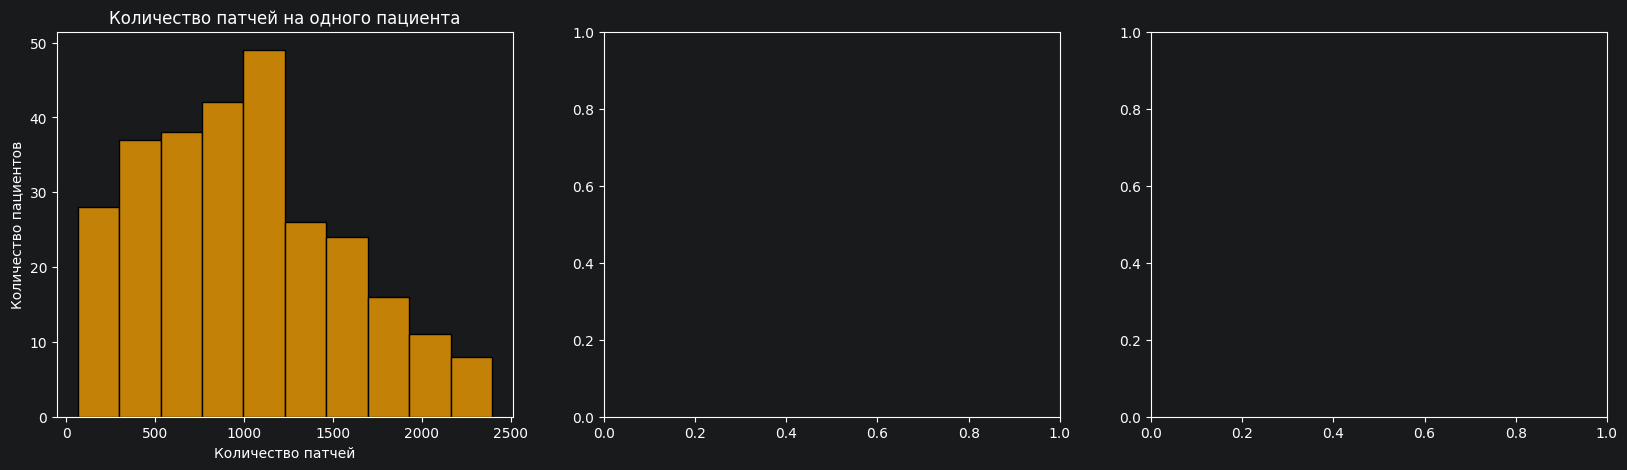

In [74]:
patient_target_counts = (
    data.groupby(["patient_id", "target"])
        .size()
        .unstack(fill_value=0)
)

fig, ax = plt.subplots(
    1,
    3,
    figsize=(20, 5)
)

patches_per_patient = patient_target_counts.sum(axis=1)
sns.histplot(
    patches_per_patient,
    ax=ax[0],
    color="orange"
)

ax[0].set_title("Количество патчей на одного пациента")
ax[0].set_xlabel("Количество патчей")
ax[0].set_ylabel("Количество пациентов")

ML

In [75]:
SEED = 42


In [76]:
np.random.seed(SEED)

In [77]:
data.target = data.target.astype(int)

In [78]:
patients = data.patient_id.unique()

sgkf_test = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

train_id, test_id = next(sgkf_test.split(X=data.path, y=data.target, groups=data.patient_id))

In [79]:
train_df = data.iloc[train_id].copy()
test_df = data.iloc[test_id].copy()

In [80]:
sgkf_val = StratifiedGroupKFold(
    n_splits=4,
    shuffle=True,
    random_state=SEED
)
train_id, val_id = next(sgkf_test.split(X=train_df.path, y=train_df.target, groups=train_df.patient_id))

In [81]:
train_df = data.iloc[train_id].copy()
val_df = data.iloc[val_id].copy()

In [82]:
train_df, _ = train_test_split(train_df, train_size=40000, stratify=train_df["target"], random_state=42)
val_df, _ = train_test_split(val_df, train_size=10000, stratify=val_df["target"], random_state=42)
test_df, _ = train_test_split(test_df, train_size=10000, stratify=test_df["target"], random_state=42)

In [83]:
OUTPUT_DIR = Path("./data/breast_cancer/splits/")
if OUTPUT_DIR.exists() and is_colab():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

splits = {
    "train": train_df,
    "val": val_df,
    "test": test_df,
}


def copy_dataframe_images(dataframe, split_name, output_dir):
    copied = 0

    for class_name in ("0", "1"):
        class_dir = output_dir / split_name / class_name
        class_dir.mkdir(parents=True, exist_ok=True)

    for row in tqdm(
        dataframe.itertuples(index=False),
        total=len(dataframe),
        desc=f"Копирование {split_name}"
    ):
        source_path = Path(row.path)
        target = str(int(row.target))


        destination_dir = output_dir / split_name / target
        destination_path = destination_dir / source_path.name

        shutil.copy2(source_path, destination_path)

        copied += 1

    print(
        f"{split_name}: скопировано {copied}"
    )


for split_name, dataframe in splits.items():
    copy_dataframe_images(
        dataframe=dataframe,
        split_name=split_name,
        output_dir=OUTPUT_DIR
    )

Копирование train: 100%|██████████| 40000/40000 [00:28<00:00, 1421.00it/s]


train: скопировано 40000


Копирование val: 100%|██████████| 10000/10000 [00:07<00:00, 1409.70it/s]


val: скопировано 10000


Копирование test: 100%|██████████| 10000/10000 [00:06<00:00, 1540.85it/s]

test: скопировано 10000


In [84]:
BATCH_SIZE = 32
IMG_SIZE = (96, 96)

In [85]:
train_ds  = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "train",
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

Found 40000 files belonging to 2 classes.


In [86]:
val_ds  = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "val",
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

Found 10000 files belonging to 2 classes.


In [87]:
test_ds  = tf.keras.utils.image_dataset_from_directory(
    OUTPUT_DIR / "test",
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

Found 10000 files belonging to 2 classes.


In [88]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [89]:
from sklearn.utils import compute_class_weight

class_weights = compute_class_weight(y=train_df.target.values, class_weight="balanced", classes=train_df.target.unique())
class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

class_weights

{0: np.float64(0.7055918151349444), 1: np.float64(1.716001716001716)}

In [90]:
augmentation = keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1)
])

In [91]:
def get_model_builder(base_model_function, preprocess_function=None):

    def build_model(hp):
        inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

        x = augmentation(inputs)

        if preprocess_function is not None:
            x = preprocess_function(x)

        base_model = base_model_function(
                include_top=False,
                weights="imagenet",
                input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
        )

        base_model.trainable = False



        dense_units = hp.Choice("dense_units", values=[64, 128, 256])
        dropout = hp.Float("dropout", min_value=0.2, max_value=0.5, step=0.1)
        learning_rate = hp.Choice("learning_rate", values=[1e-3, 3e-4, 1e-4])

        x = base_model(x, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(dense_units, activation="relu")(x)
        x = layers.Dropout(dropout)(x)
        outputs = layers.Dense(1, activation="sigmoid")(x)

        model = keras.Model(inputs, outputs)

        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
            loss="binary_crossentropy",
            metrics=[keras.metrics.AUC(name="pr_auc", curve="PR")],
        )
        return model

    return build_model

In [92]:
def tune_model(base_model_function, preprocess_function, model_name):
    model_builder = get_model_builder(base_model_function, preprocess_function)

    tuner = keras_tuner.Hyperband(
        model_builder,
        objective=keras_tuner.Objective("val_pr_auc", direction="max"),
        max_epochs=10,
        factor=3,
        directory="./tuner_results",
        project_name=model_name,
        overwrite=True
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=2,
        restore_best_weights=True
    )

    tuner.search(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        class_weight=class_weights,
        callbacks=[early_stopping]
    )

    best_parameters = tuner.get_best_hyperparameters(1)[0]

    print("Лучшие параметры:")
    print("Dense:", best_parameters.get("dense_units"))
    print("Dropout:", best_parameters.get("dropout"))
    print("Learning rate:", best_parameters.get("learning_rate"))

    best_model = tuner.hypermodel.build(best_parameters)

    return best_model, best_parameters, tuner

In [93]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


In [94]:
resnet_model, resnet_parameters, resnet_tuner = tune_model(
    keras.applications.ResNet50V2,
    keras.applications.resnet_v2.preprocess_input,
    "resnet50v2"
)

Trial 9 Complete [00h 04m 31s]
val_pr_auc: 0.810266375541687

Best val_pr_auc So Far: 0.8133963346481323
Total elapsed time: 00h 39m 27s

Search: Running Trial #10

Value             |Best Value So Far |Hyperparameter
64                |128               |dense_units
0.3               |0.3               |dropout
0.0003            |0.001             |learning_rate
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2
 954/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 85ms/step - loss: 0.5330 - pr_auc: 0.6482

KeyboardInterrupt: 